# 06 - Evaluation and Recommendations

Final synthesis of clustering, classification and regression outputs.


In [1]:
from pathlib import Path
from IPython.display import display
import joblib
import matplotlib.pyplot as plt
import pandas as pd

REPORTS_DIR = Path('../reports')
MODEL_DIR = Path('../models')
print('Environment ready')


Environment ready


In [2]:
classification_results = pd.read_csv(REPORTS_DIR / 'classification_results.csv')
cluster_summary = pd.read_csv(REPORTS_DIR / 'cluster_summary.csv')
regression_results = pd.read_csv(REPORTS_DIR / 'regression_results.csv')
print('Reports loaded')
print('classification_results:', classification_results.shape)
print('cluster_summary:', cluster_summary.shape)
print('regression_results:', regression_results.shape)


Reports loaded
classification_results: (4, 6)
cluster_summary: (3, 3)
regression_results: (2, 4)


In [3]:
print('Classification models ranked by F1-score')
display(classification_results.sort_values('F1-score', ascending=False).round(4))


Classification models ranked by F1-score


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Random Forest sans PCA,1.0000,1.0000,1.0000,1.0000,1.0000
0,Logistic Regression sans PCA,0.9977,0.9966,0.9966,0.9966,0.9998
2,Logistic Regression avec PCA,0.9646,0.9452,0.9485,0.9468,0.9928
3,Random Forest avec PCA,0.9600,0.9923,0.8866,0.9365,0.9871


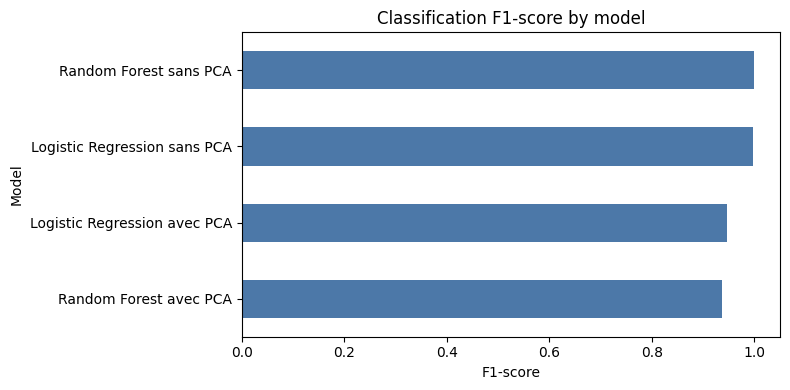

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
classification_results.sort_values('F1-score').plot(kind='barh', x='Model', y='F1-score', ax=ax, legend=False, color='#4c78a8')
ax.set_title('Classification F1-score by model')
ax.set_xlabel('F1-score')
plt.tight_layout()
plt.show()


In [5]:
cluster_eval = cluster_summary.copy()
cluster_eval['Customer_Share'] = (cluster_eval['Number_of_Customers'] / cluster_eval['Number_of_Customers'].sum() * 100).round(2)
print('Cluster risk ranking')
display(cluster_eval.sort_values('Churn_Rate', ascending=False).round(2))


Cluster risk ranking


,Cluster,Number_of_Customers,Churn_Rate,Customer_Share
2,2,2,50.00,0.06
0,0,3480,33.39,99.51
1,1,15,0.00,0.43


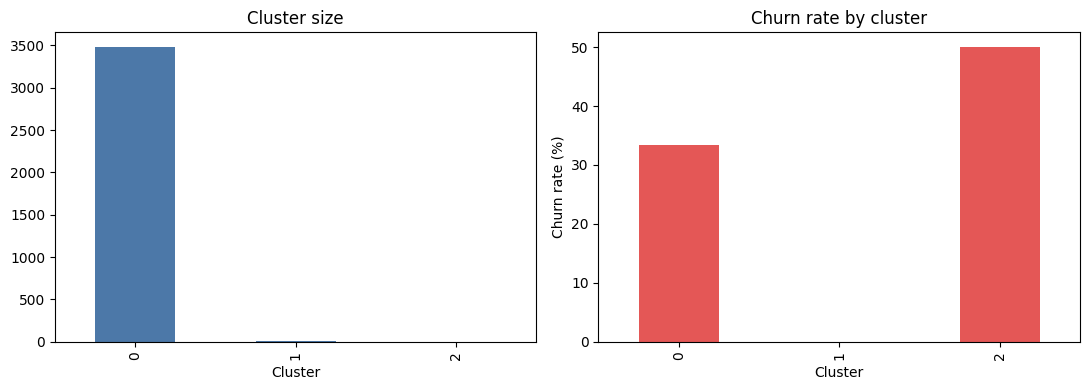

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cluster_eval.plot(kind='bar', x='Cluster', y='Number_of_Customers', ax=axes[0], legend=False, color='#4c78a8')
axes[0].set_title('Cluster size')
cluster_eval.plot(kind='bar', x='Cluster', y='Churn_Rate', ax=axes[1], legend=False, color='#e45756')
axes[1].set_title('Churn rate by cluster')
axes[1].set_ylabel('Churn rate (%)')
plt.tight_layout()
plt.show()


In [7]:
print('Regression models ranked by RMSE')
display(regression_results.sort_values('RMSE').round(3))


Regression models ranked by RMSE


,Model,MAE,RMSE,R2
0,Linear Regression,840.507,6603.897,0.661
1,Random Forest Regressor,741.016,7342.255,0.581


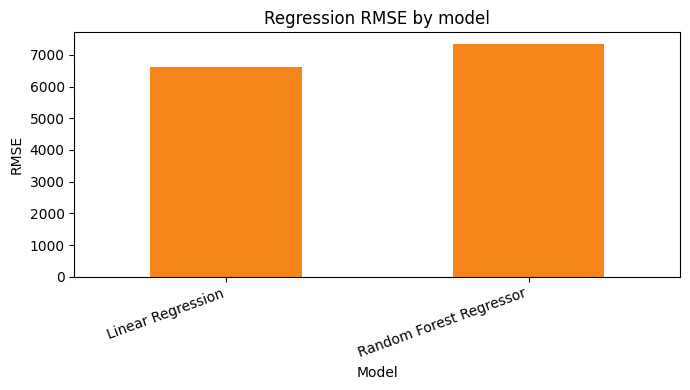

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
regression_results.sort_values('RMSE').plot(kind='bar', x='Model', y='RMSE', ax=ax, legend=False, color='#f58518')
ax.set_title('Regression RMSE by model')
ax.set_ylabel('RMSE')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


In [9]:
best_churn_metadata = joblib.load(MODEL_DIR / 'best_churn_model_metadata.joblib')
best_churn_model = joblib.load(MODEL_DIR / 'best_churn_model.joblib')
best_regression_model = joblib.load(MODEL_DIR / 'best_regression_model.joblib')
kmeans_model = joblib.load(MODEL_DIR / 'kmeans_customer_segments.joblib')
print('Best churn metadata:', best_churn_metadata)
print('Best churn model:', type(best_churn_model).__name__)
print('Best regression model:', type(best_regression_model).__name__)
print('Clustering model:', type(kmeans_model).__name__, 'with', kmeans_model.n_clusters, 'clusters')


Best churn metadata: {'best_model_name': 'Random Forest sans PCA', 'best_f1_score': 1.0, 'use_pca': False}
Best churn model: RandomForestClassifier
Best regression model: Pipeline
Clustering model: KMeans with 3 clusters


In [10]:
actions = pd.DataFrame([
    {'Priority': 1, 'Action': 'Score customers with churn classifier', 'Expected use': 'Identify customers likely to churn'},
    {'Priority': 2, 'Action': 'Target high-risk clusters', 'Expected use': 'Focus retention budget on risky segments'},
    {'Priority': 3, 'Action': 'Use monetary prediction', 'Expected use': 'Prioritize high-value customers'},
    {'Priority': 4, 'Action': 'Monitor precision and recall', 'Expected use': 'Balance false positives and false negatives'},
    {'Priority': 5, 'Action': 'Retrain on refreshed data', 'Expected use': 'Keep model behavior aligned with recent customers'},
])
print('Recommended action plan')
display(actions)


Recommended action plan


,Priority,Action,Expected use
0,1,Score customers with churn classifier,Identify customers likely to churn
1,2,Target high-risk clusters,Focus retention budget on risky segments
2,3,Use monetary prediction,Prioritize high-value customers
3,4,Monitor precision and recall,Balance false positives and false negatives
4,5,Retrain on refreshed data,Keep model behavior aligned with recent customers


## Final recommendation

Deploy the churn classifier for customer scoring, combine it with cluster risk information, and use regression outputs to prioritize high-value retention actions.
